示例1:


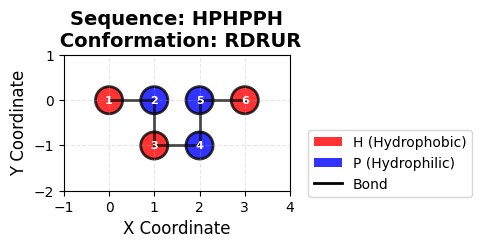

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_polymer_conformation(sequence, conformation, figsize=(5, 4)):
    """
    在格子模型中绘制polymer构象
    
    参数:
    sequence: str - HP字符串，H(疏水红球)，P(亲水蓝球)
    conformation: str - 构象字符串，U(上), D(下), L(左), R(右)
    figsize: tuple - 图形大小
    """
    
    # 颜色映射
    color_map = {'H': 'red', 'P': 'blue'}
    label_map = {'H': 'Hydrophobic', 'P': 'Hydrophilic'}
    
    # 验证输入
    if len(sequence) != len(conformation) + 1:
        raise ValueError(f"序列长度({len(sequence)})应该比构象长度({len(conformation)})多1")
    
    # 计算格子坐标
    coords = [(0, 0)]  # 起始位置
    x, y = 0, 0
    
    # 方向映射
    direction_map = {'U': (0, 1), 'D': (0, -1), 'L': (-1, 0), 'R': (1, 0)}
    
    for move in conformation:
        dx, dy = direction_map[move]
        x += dx
        y += dy
        coords.append((x, y))
    
    # 提取坐标范围
    xs = [coord[0] for coord in coords]
    ys = [coord[1] for coord in coords]
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    # 绘制连接线
    for i in range(len(coords) - 1):
        x1, y1 = coords[i]
        x2, y2 = coords[i + 1]
        ax.plot([x1, x2], [y1, y2], 'k-', linewidth=2, alpha=0.7)
    
    # 绘制珠子
    for i, ((x, y), residue) in enumerate(zip(coords, sequence)):
        color = color_map[residue]
        
        # 绘制珠子（圆形）
        circle = patches.Circle((x, y), radius=0.3, facecolor=color, 
                               edgecolor='black', linewidth=2, alpha=0.8)
        ax.add_patch(circle)
        
        # 添加序号标签
        ax.text(x, y, str(i+1), ha='center', va='center', 
               fontweight='bold', fontsize=8, color='white')
    
    # 设置坐标轴
    margin = 1
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)
    ax.set_aspect('equal')
    
    # 添加网格
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(np.arange(min(xs)-1, max(xs)+2))
    ax.set_yticks(np.arange(min(ys)-1, max(ys)+2))
    
    # 添加标题和标签
    ax.set_title(f'Sequence: {sequence}\n Conformation: {conformation}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('X Coordinate', fontsize=12)
    ax.set_ylabel('Y Coordinate', fontsize=12)
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.8, label='H (Hydrophobic)'),
        Patch(facecolor='blue', alpha=0.8, label='P (Hydrophilic)'),
        plt.Line2D([0], [0], color='black', linewidth=2, label='Bond')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 0.5))
    
    plt.tight_layout()
    plt.show()
    
    return coords

def plot_polymer_with_contacts(sequence, conformation, figsize=(12, 8)):
    """
    绘制polymer构象并高亮显示疏水接触
    """
    
    # 验证输入
    if len(sequence) != len(conformation) + 1:
        raise ValueError(f"序列长度({len(sequence)})应该比构象长度({len(conformation)})多1")
    
    # 计算格子坐标
    coords = [(0, 0)]  # 起始位置
    x, y = 0, 0
    direction_map = {'U': (0, 1), 'D': (0, -1), 'L': (-1, 0), 'R': (1, 0)}
    
    for move in conformation:
        dx, dy = direction_map[move]
        x += dx
        y += dy
        coords.append((x, y))
    
    # 检测疏水接触（非相邻的H-H接触）
    contacts = []
    n = len(coords)  # 珠子数量
    
    for i in range(n):
        for j in range(i + 2, n):  # 跳过相邻的珠子
            # 确保索引在序列范围内
            if i < len(sequence) and j < len(sequence):
                if sequence[i] == 'H' and sequence[j] == 'H':
                    # 检查是否在相邻格子（曼哈顿距离为1）
                    dx = abs(coords[i][0] - coords[j][0])
                    dy = abs(coords[i][1] - coords[j][1])
                    if dx + dy == 1:  # 曼哈顿距离为1表示接触
                        contacts.append((i, j))
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # 提取坐标范围
    xs = [coord[0] for coord in coords]
    ys = [coord[1] for coord in coords]
    
    # 绘制连接线
    for i in range(len(coords) - 1):
        x1, y1 = coords[i]
        x2, y2 = coords[i + 1]
        ax1.plot([x1, x2], [y1, y2], 'k-', linewidth=2, alpha=0.7)
        ax2.plot([x1, x2], [y1, y2], 'k-', linewidth=2, alpha=0.7)
    
    # 绘制珠子
    for i, ((x, y), residue) in enumerate(zip(coords, sequence)):
        color = 'red' if residue == 'H' else 'blue'
        
        for ax in [ax1, ax2]:
            circle = patches.Circle((x, y), radius=0.3, facecolor=color, 
                                   edgecolor='black', linewidth=2, alpha=0.8)
            ax.add_patch(circle)
            ax.text(x, y, str(i+1), ha='center', va='center', 
                   fontweight='bold', fontsize=8, color='white')
    
    # 在右图中高亮显示接触
    for i, j in contacts:
        x1, y1 = coords[i]
        x2, y2 = coords[j]
        ax2.plot([x1, x2], [y1, y2], 'g--', linewidth=3, alpha=0.6, 
                label='H-H Contact' if (i,j) == contacts[0] else "")
    
    # 设置两个子图
    for ax in [ax1, ax2]:
        margin = 1
        ax.set_xlim(min(xs) - margin, max(xs) + margin)
        ax.set_ylim(min(ys) - margin, max(ys) + margin)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xticks(np.arange(min(xs)-1, max(xs)+2))
        ax.set_yticks(np.arange(min(ys)-1, max(ys)+2))
    
    ax1.set_title('Basic Conformation', fontsize=12, fontweight='bold')
    ax2.set_title(f'With Hydrophobic Contacts (Found: {len(contacts)})', 
                 fontsize=12, fontweight='bold')
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.8, label='H (Hydrophobic)'),
        Patch(facecolor='blue', alpha=0.8, label='P (Hydrophilic)'),
        plt.Line2D([0], [0], color='black', linewidth=2, label='Bond'),
        plt.Line2D([0], [0], color='green', linestyle='--', linewidth=2, label='H-H Contact')
    ]
    ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 0.5))
    
    plt.tight_layout()
    plt.show()
    
    print(f"序列: {sequence}")
    print(f"构象: {conformation}")
    print(f"珠子坐标: {coords}")
    print(f"找到 {len(contacts)} 个疏水接触: {contacts}")
    
    return coords, contacts

# 修正后的使用示例
if __name__ == "__main__":
    # 示例1：简单构象
    sequence1 = "HPHPPH"
    conformation1 = "RDRUR"
    
    print("示例1:")
    coords1 = plot_polymer_conformation(sequence1, conformation1)
    #print("坐标:", coords1)

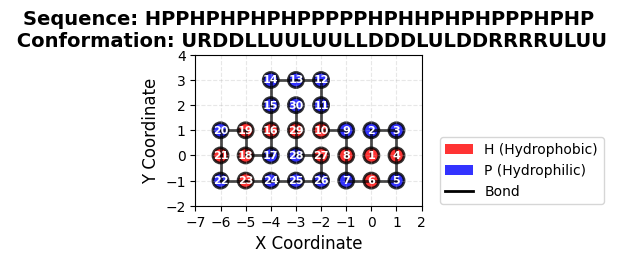

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
sequence = "HPPHPHPHPHPPPPPHPHHPHPHPPPHPHP"
conformation = "URDDLLUULUULLDDDLULDDRRRRULUU"
coords = plot_polymer_conformation(sequence, conformation)

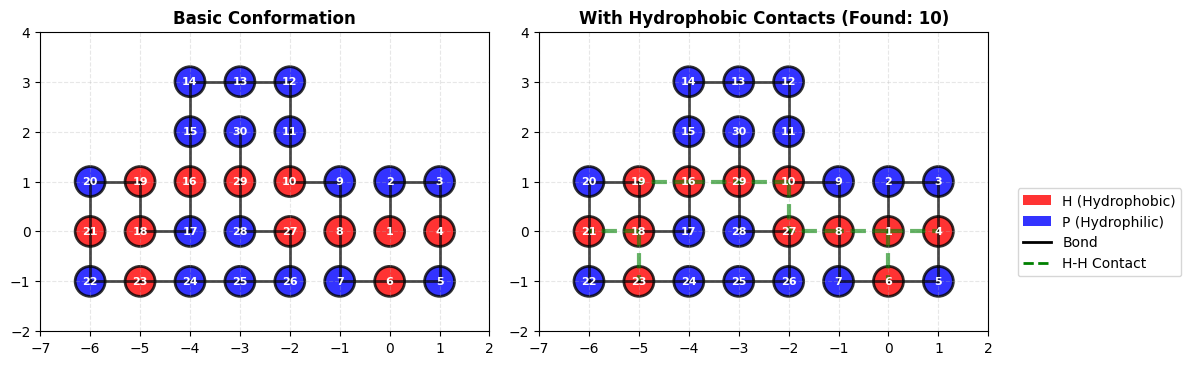

序列: HPPHPHPHPHPPPPPHPHHPHPHPPPHPHP
构象: URDDLLUULUULLDDDLULDDRRRRULUU
珠子坐标: [(0, 0), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1), (-1, 0), (-1, 1), (-2, 1), (-2, 2), (-2, 3), (-3, 3), (-4, 3), (-4, 2), (-4, 1), (-4, 0), (-5, 0), (-5, 1), (-6, 1), (-6, 0), (-6, -1), (-5, -1), (-4, -1), (-3, -1), (-2, -1), (-2, 0), (-3, 0), (-3, 1), (-3, 2)]
找到 10 个疏水接触: [(0, 3), (0, 5), (0, 7), (7, 26), (9, 26), (9, 28), (15, 18), (15, 28), (17, 20), (17, 22)]


In [3]:
sequence = "HPPHPHPHPHPPPPPHPHHPHPHPPPHPHP"
conformation = "URDDLLUULUULLDDDLULDDRRRRULUU"
coords = plot_polymer_with_contacts(sequence, conformation)

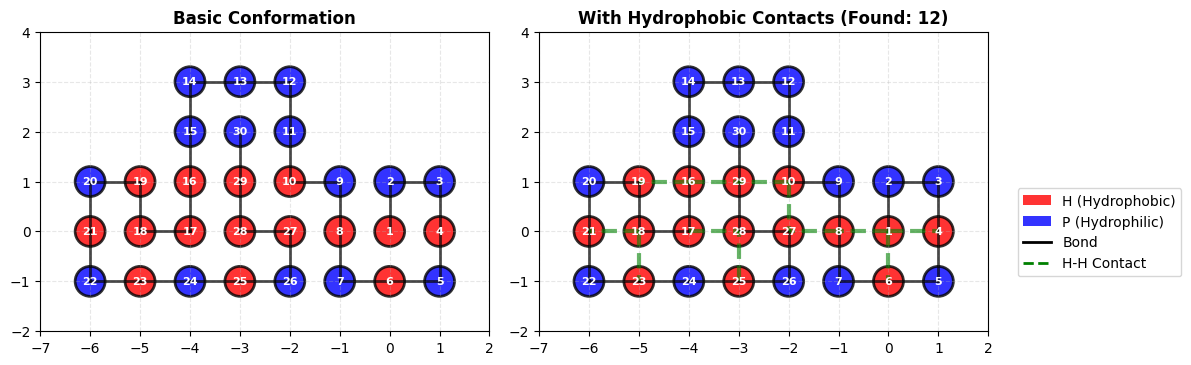

序列: HPPHPHPHPHPPPPPHHHHPHPHPHPHHHP
构象: URDDLLUULUULLDDDLULDDRRRRULUU
珠子坐标: [(0, 0), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1), (-1, 0), (-1, 1), (-2, 1), (-2, 2), (-2, 3), (-3, 3), (-4, 3), (-4, 2), (-4, 1), (-4, 0), (-5, 0), (-5, 1), (-6, 1), (-6, 0), (-6, -1), (-5, -1), (-4, -1), (-3, -1), (-2, -1), (-2, 0), (-3, 0), (-3, 1), (-3, 2)]
找到 12 个疏水接触: [(0, 3), (0, 5), (0, 7), (7, 26), (9, 26), (9, 28), (15, 18), (15, 28), (16, 27), (17, 20), (17, 22), (24, 27)]


In [4]:
sequence2 = "HPPHPHPHPHPPPPPHHHHPHPHPHPHHHP"  # 长度11
conformation2 = "URDDLLUULUULLDDDLULDDRRRRULUU"  # 长度10，这样11 = 10 + 1
coords2, contacts2 = plot_polymer_with_contacts(sequence2, conformation2)